# **Data Demo**

This notebook demonstrates the dataset used for PokéNet by loading a few example data points to show what data looks like and what it contains.

## **Data Setup & Preparation**

Before we load specific examples, we import the necessary packages, download the dataset from Kaggle, and set up the directory.

In [1]:
# Imports
import os
import sys
import torch
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Download the dataset from Kaggle
import kagglehub

path = kagglehub.dataset_download("noodulz/pokemon-dataset-1000")
print("Path to dataset files:", path)

Path to dataset files: /home/mzhan/.cache/kagglehub/datasets/noodulz/pokemon-dataset-1000/versions/2


## **Dataset Overview**

The dataset I will be using for this project is titled [**"1000 Pokemon Dataset"**](https://www.kaggle.com/datasets/noodulz/pokemon-dataset-1000/data) from Kaggle. The dataset contains ~40 images per 1,000 Pokémon species, totaling 26,539 images and 1,000 classes. Each image is resized to 128x128 pixels and stores as a PNG file.

Fortunately, the dataset has already been split into an 80% training set, 10% evaluation set, and 10% test set. Each split has around 1000 directories except for the validation split, which has 898 directories.

In [6]:
base = os.path.join(path, "pokemon-dataset-1000")

# Count the number of species in each split
for split in ["train", "val", "test"]:
    split_path = os.path.join(base, split)
    total_species = 0
    total_images = 0
    image_extensions = (".jpeg", ".jpg", ".png")
    for directory in os.listdir(split_path):
        if os.path.isdir(os.path.join(split_path, directory)):
            total_species += 1
            for file in os.listdir(os.path.join(split_path, directory)):
                if file.endswith(image_extensions):
                    total_images += 1
    print(f"{split}: {total_species} species | {total_images} images ")

# Sort and confirm the labels for each species
classes = sorted(os.listdir(split_path))
classes[:5]

train: 1000 species | 20921 images 
val: 898 species | 2379 images 
test: 1000 species | 3239 images 


['abomasnow', 'abra', 'absol', 'accelgor', 'aegislash-shield']

## **DataLoader Setup**

In [7]:
from pokenet.dataloader import PokemonDataset, data_transform, get_data_loaders, image_extensions

train_loader, validation_loader, test_loader = get_data_loaders(base_path = os.path.join(path, "pokemon-dataset-1000"), batch_size = 5)

In [8]:
# Sanity check
images, labels = next(iter(train_loader))
print(images.shape)

train_loader.dataset

# Check validation set
print(f"Validation samples: {len(validation_loader.dataset)}")
print(f"Number of classes in val: {len(validation_loader.dataset.species_to_index)}")

# Check if val and train have the same species_to_index mapping
train_species = set(train_loader.dataset.species_to_index.keys())
val_species = set(validation_loader.dataset.species_to_index.keys())

print(f"Species in train: {len(train_species)}")
print(f"Species in val: {len(val_species)}")
print(f"Species in train but not val: {len(train_species - val_species)}")
print(f"Species in val but not train: {len(val_species - train_species)}")

torch.Size([64, 3, 256, 256])
Validation samples: 2379
Number of classes in val: 898
Species in train: 1000
Species in val: 898
Species in train but not val: 102
Species in val but not train: 0


## **Example Points**

We will load batches of Pokémon images and their corresponding name.

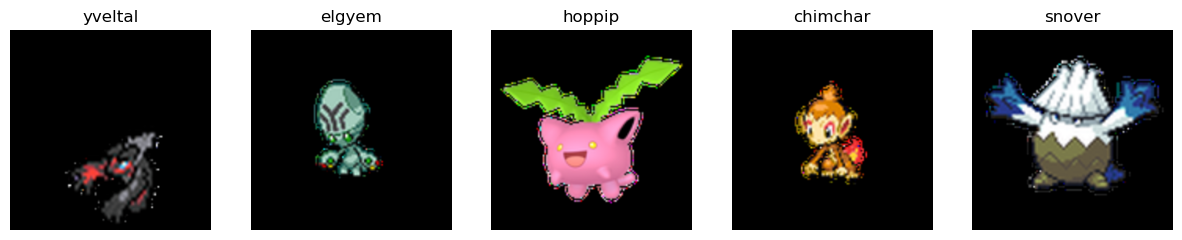

In [89]:
# Undo normalization
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

plot_images = images * torch.tensor(std).view(1, 3, 1, 1) + torch.tensor(mean).view(1, 3, 1, 1)
plot_images = (plot_images * 255.0).numpy().transpose(0, 2, 3, 1).astype(np.uint8)

index_to_species = {index: label for label, index in train_loader.dataset.species_to_index.items()}
# print(list(index_to_species.items())[:5])

# Plot images
fig, axes = plt.subplots(1, 5, figsize = (15, 3))
for i, ax in enumerate(axes):
    ax.imshow(plot_images[i])
    ax.set_title(index_to_species[labels[i].item()])
    ax.axis("off")